In [11]:
# Import libaries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [12]:
# Load in dataset and preview
df = pd.read_csv('../data/mlb_team_wins_cleaned.csv')
print(df.head())
df.shape

   yearID teamID   W   L      R     RA     HR      SO   ERA      E  \
0    2000    ANA  82  80  864.0  869.0  236.0  1024.0  5.00  134.0   
1    2000    ARI  85  77  792.0  754.0  179.0   975.0  4.35  107.0   
2    2000    ATL  95  67  810.0  714.0  179.0  1010.0  4.05  129.0   
3    2000    BAL  74  88  794.0  913.0  184.0   900.0  5.37  116.0   
4    2000    BOS  85  77  792.0  745.0  167.0  1019.0  4.23  109.0   

   attendance  run_diff   win_pct  
0   2066982.0      -5.0  0.506173  
1   2942251.0      38.0  0.524691  
2   3234304.0      96.0  0.586420  
3   3297031.0    -119.0  0.456790  
4   2585895.0      47.0  0.524691  


(750, 13)

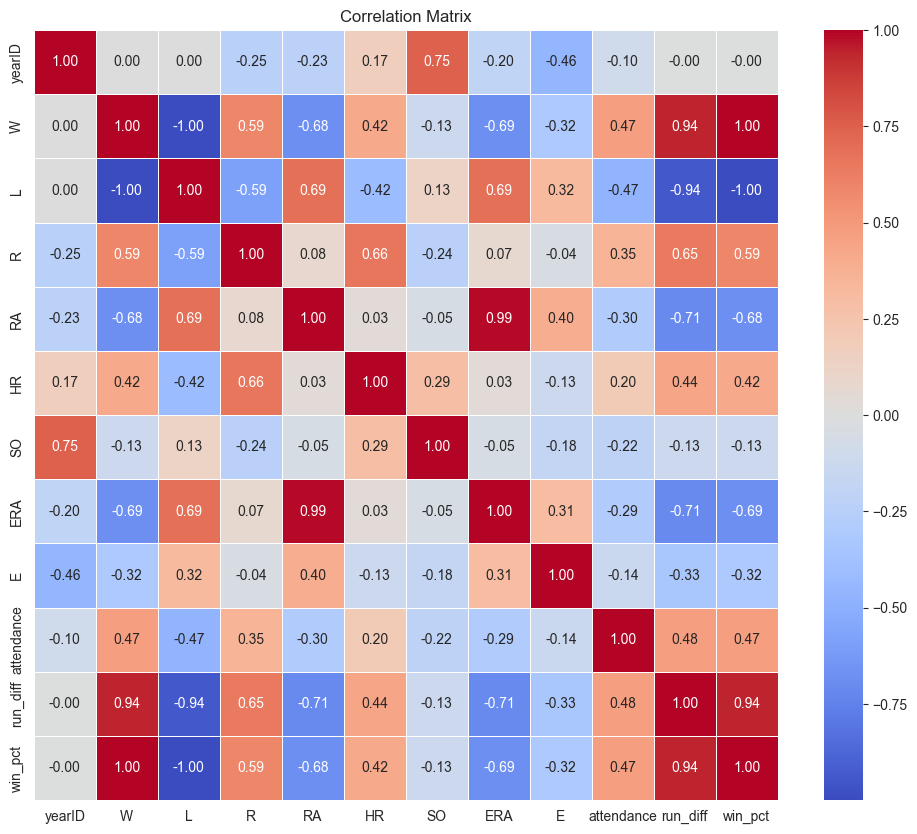

In [13]:
# Correlation Analysis - Correlation Matrix and Heatmap
corr = df.corr(numeric_only=True)
corr['W'].sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


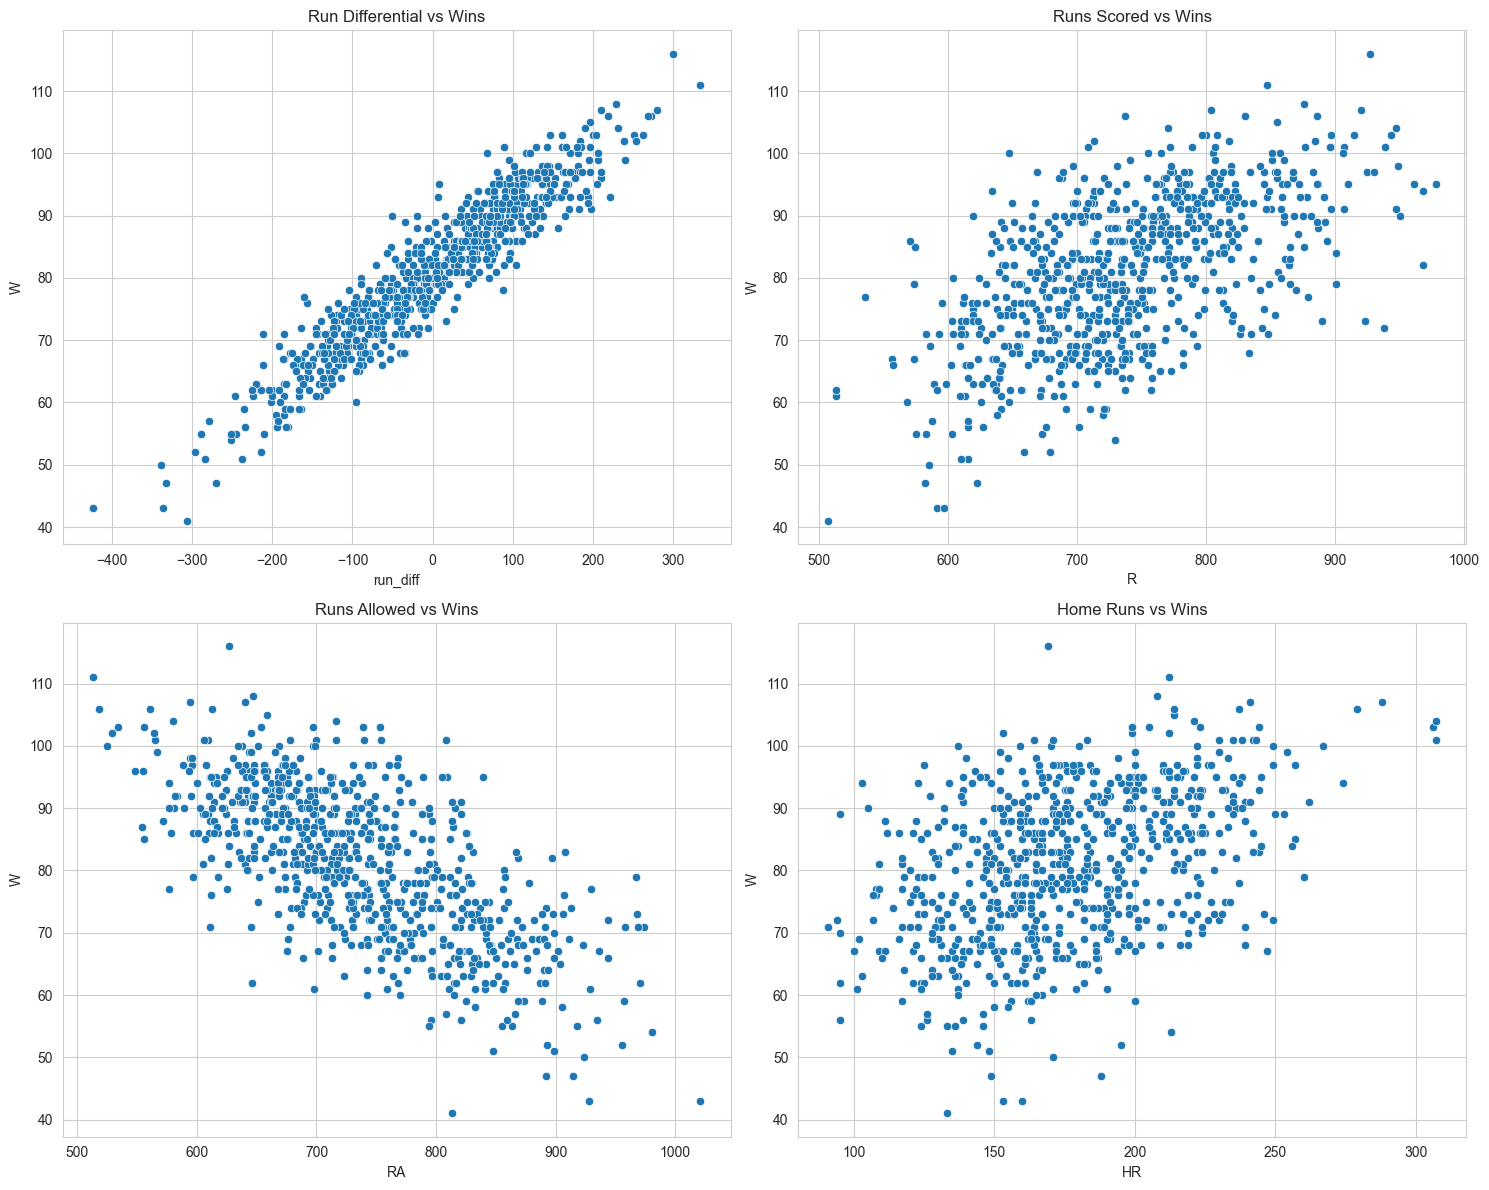

In [14]:
# Wins Analysis vs Runs Differential, Runs Scored, Runs Allowed, and Home Runs
fig, axes = plt.subplots(2, 2, figsize=(15,12))

# Chart 1 - Run Differential vs Wins
sns.scatterplot(data=df, x='run_diff', y='W', ax=axes[0,0])
axes[0,0].set_title('Run Differential vs Wins')

# Chart 2 - Runs Scored vs Wins
sns.scatterplot(data=df, x='R', y='W', ax=axes[0,1])
axes[0,1].set_title('Runs Scored vs Wins')

# Chart 3 - Runs Allowed vs Wins
sns.scatterplot(data=df, x='RA', y='W', ax=axes[1,0])
axes[1,0].set_title('Runs Allowed vs Wins')

# Chart 4 - Home Runs vs Wins
sns.scatterplot(data=df, x='HR', y='W', ax=axes[1,1])
axes[1,1].set_title('Home Runs vs Wins')

plt.tight_layout()
plt.show()

__Key Insight:__

Run Differential appears to be the strongest predictor of wins, while home runs alone are less predictive than total team performance.

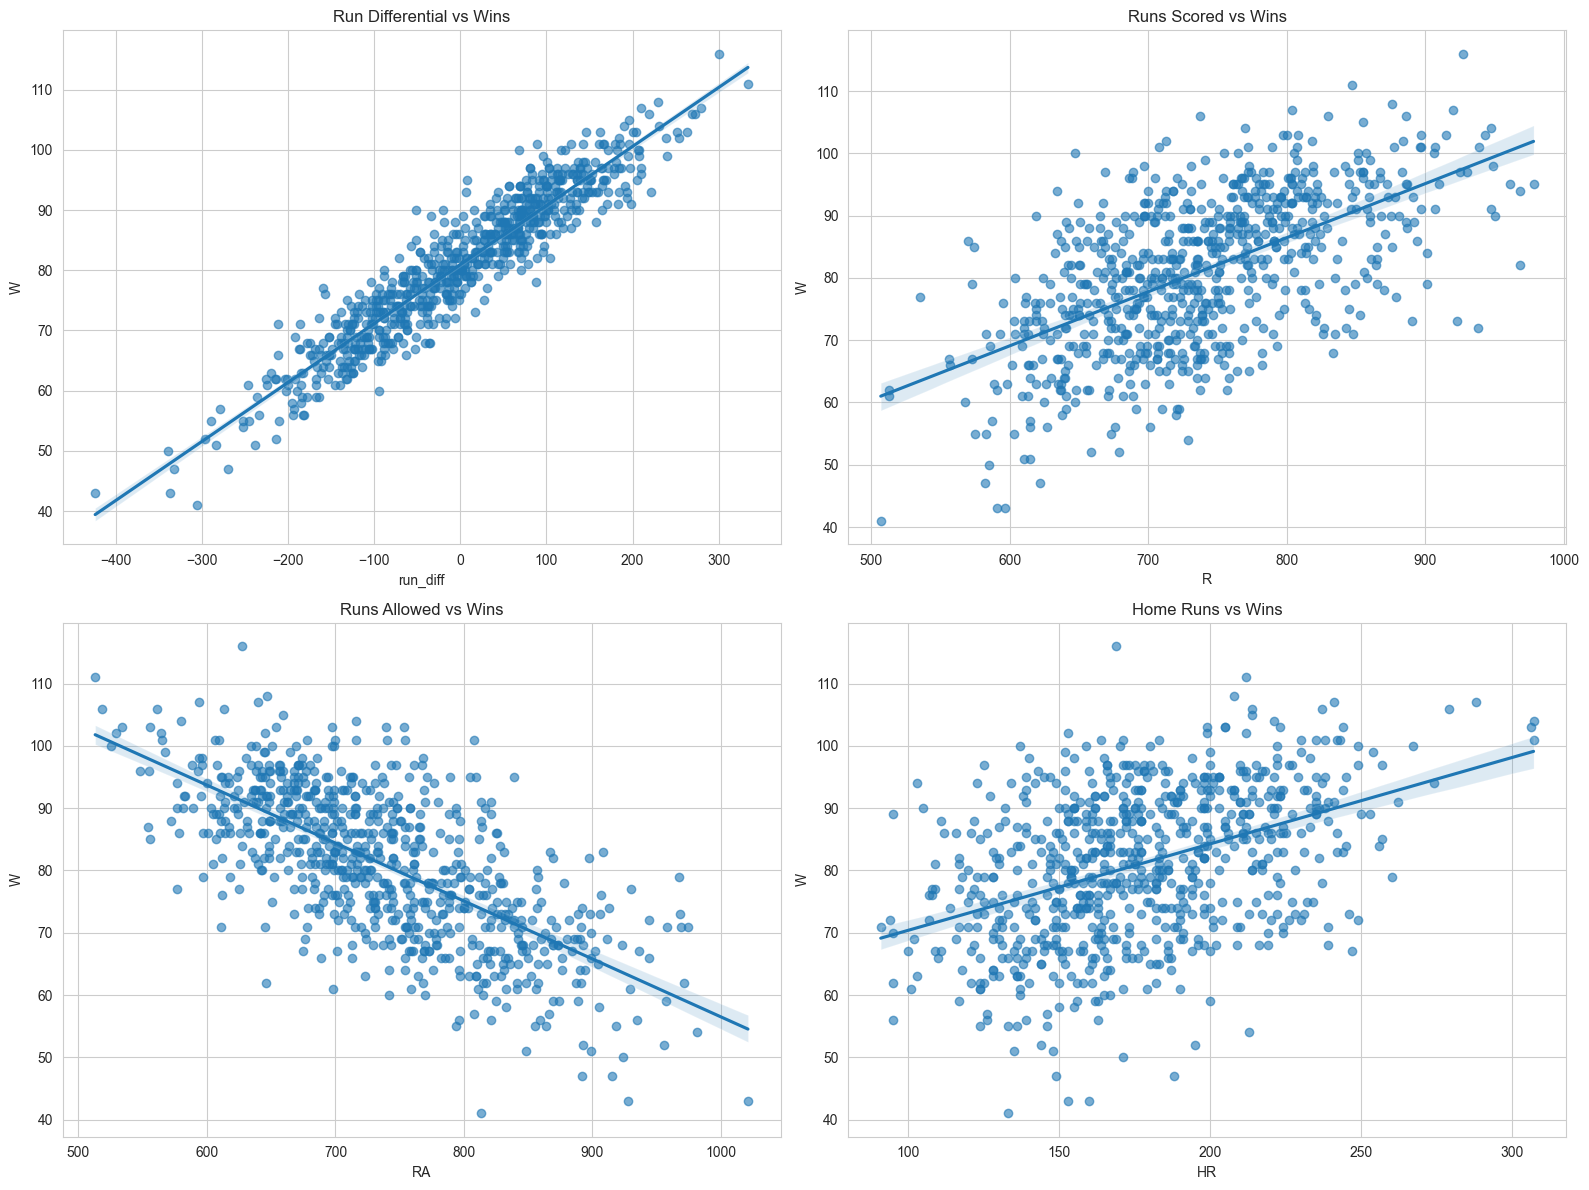

In [16]:
# Adding regression lines to the scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(data=df, x="run_diff", y="W", ax=axes[0,0], scatter_kws={"alpha":0.6})
axes[0,0].set_title("Run Differential vs Wins")

sns.regplot(data=df, x="R", y="W", ax=axes[0,1], scatter_kws={"alpha":0.6})
axes[0,1].set_title("Runs Scored vs Wins")

sns.regplot(data=df, x="RA", y="W", ax=axes[1,0], scatter_kws={"alpha":0.6})
axes[1,0].set_title("Runs Allowed vs Wins")

sns.regplot(data=df, x="HR", y="W", ax=axes[1,1], scatter_kws={"alpha":0.6})
axes[1,1].set_title("Home Runs vs Wins")

plt.tight_layout()
plt.show()

In [17]:
# Best teams since 2000 based on wins
df.sort_values(by='W', ascending=False)[['yearID', 'teamID', 'W', 'run_diff']].head(10)

,yearID,teamID,W,run_diff
54,2001,SEA,116,300.0
643,2022,LAN,111,334.0
543,2018,BOS,108,229.0
580,2019,HOU,107,280.0
624,2021,SFN,107,210.0
583,2019,LAN,106,273.0
613,2021,LAN,106,269.0
640,2022,HOU,106,219.0
146,2004,SLN,105,196.0
661,2023,ATL,104,231.0


Good Future Analysis:
What separates elite teams?

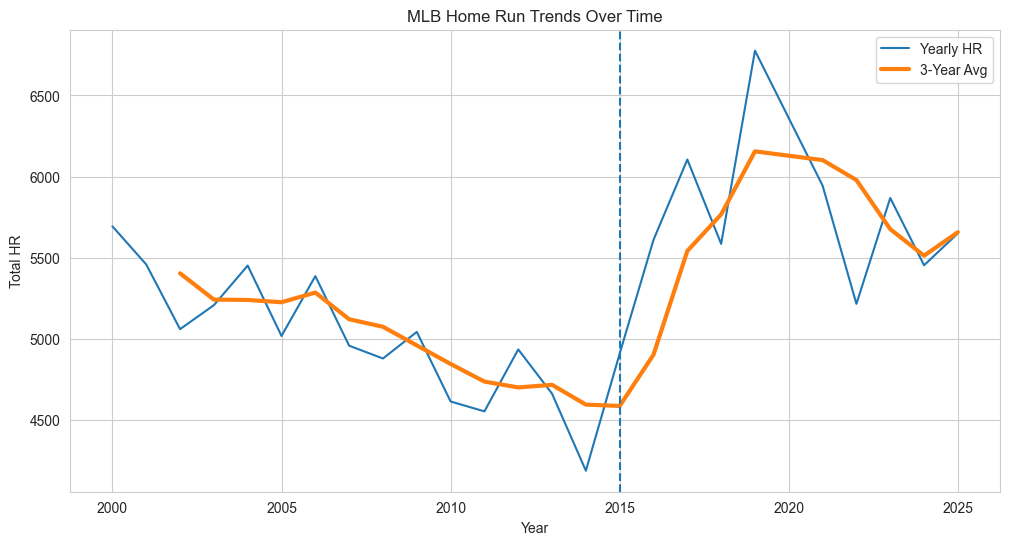

In [23]:
# Average HR by Year
hr_year = df.groupby("yearID")["HR"].sum()

rolling_hr = hr_year.rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(hr_year, label="Yearly HR")
plt.plot(rolling_hr, label="3-Year Avg", linewidth=3)
plt.axvline(x=2015, linestyle="--")
plt.title("MLB Home Run Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Total HR")
plt.legend()

plt.show()

Home runs increased significantly in the mid-to-late 2010s, reflecting changes in hitting approach and possible ball composition changes.

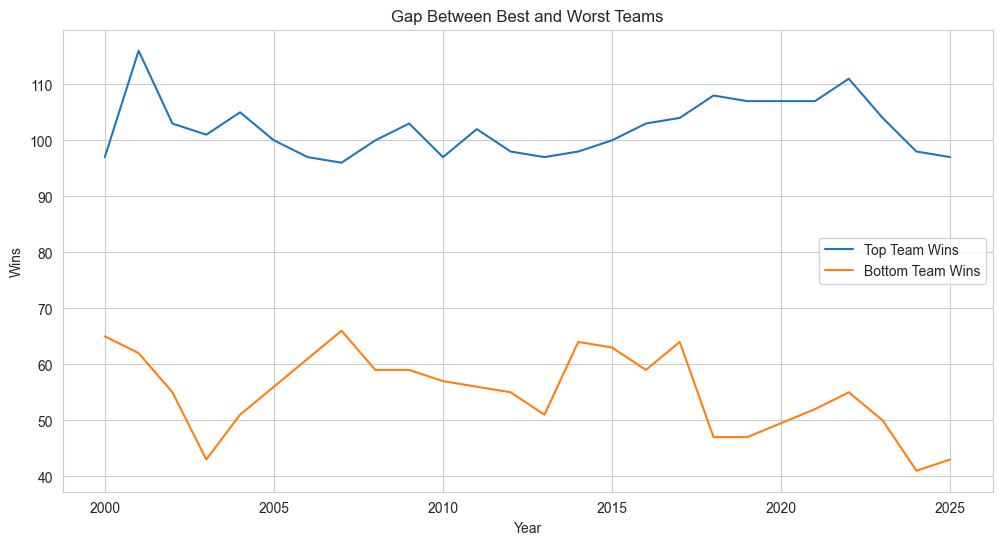

In [24]:
# Average Wins per Year
top_wins = df.groupby("yearID")["W"].max()
bottom_wins = df.groupby("yearID")["W"].min()

plt.figure(figsize=(12,6))

plt.plot(top_wins, label="Top Team Wins")
plt.plot(bottom_wins, label="Bottom Team Wins")

plt.title("Gap Between Best and Worst Teams")
plt.xlabel("Year")
plt.ylabel("Wins")
plt.legend()

plt.show()

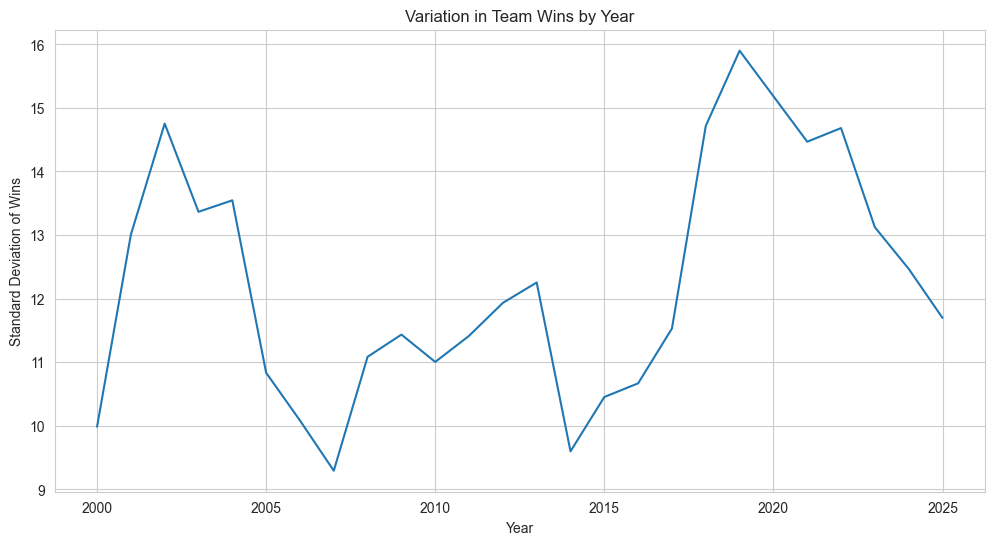

In [26]:
win_std = df.groupby("yearID")["W"].std()

plt.figure(figsize=(12,6))
win_std.plot()

plt.title("Variation in Team Wins by Year")
plt.xlabel("Year")
plt.ylabel("Standard Deviation of Wins")

plt.show()

The gap between the best and worst teams varies across seasons, indicating changes in league parity and competitiveness over time.

In [27]:
# Look at strong correlations
corr["W"].sort_values(ascending=False)[1:8]

win_pct       0.999918
run_diff      0.941673
R             0.589867
attendance    0.474470
HR            0.421762
yearID        0.001461
SO           -0.125110
Name: W, dtype: float64

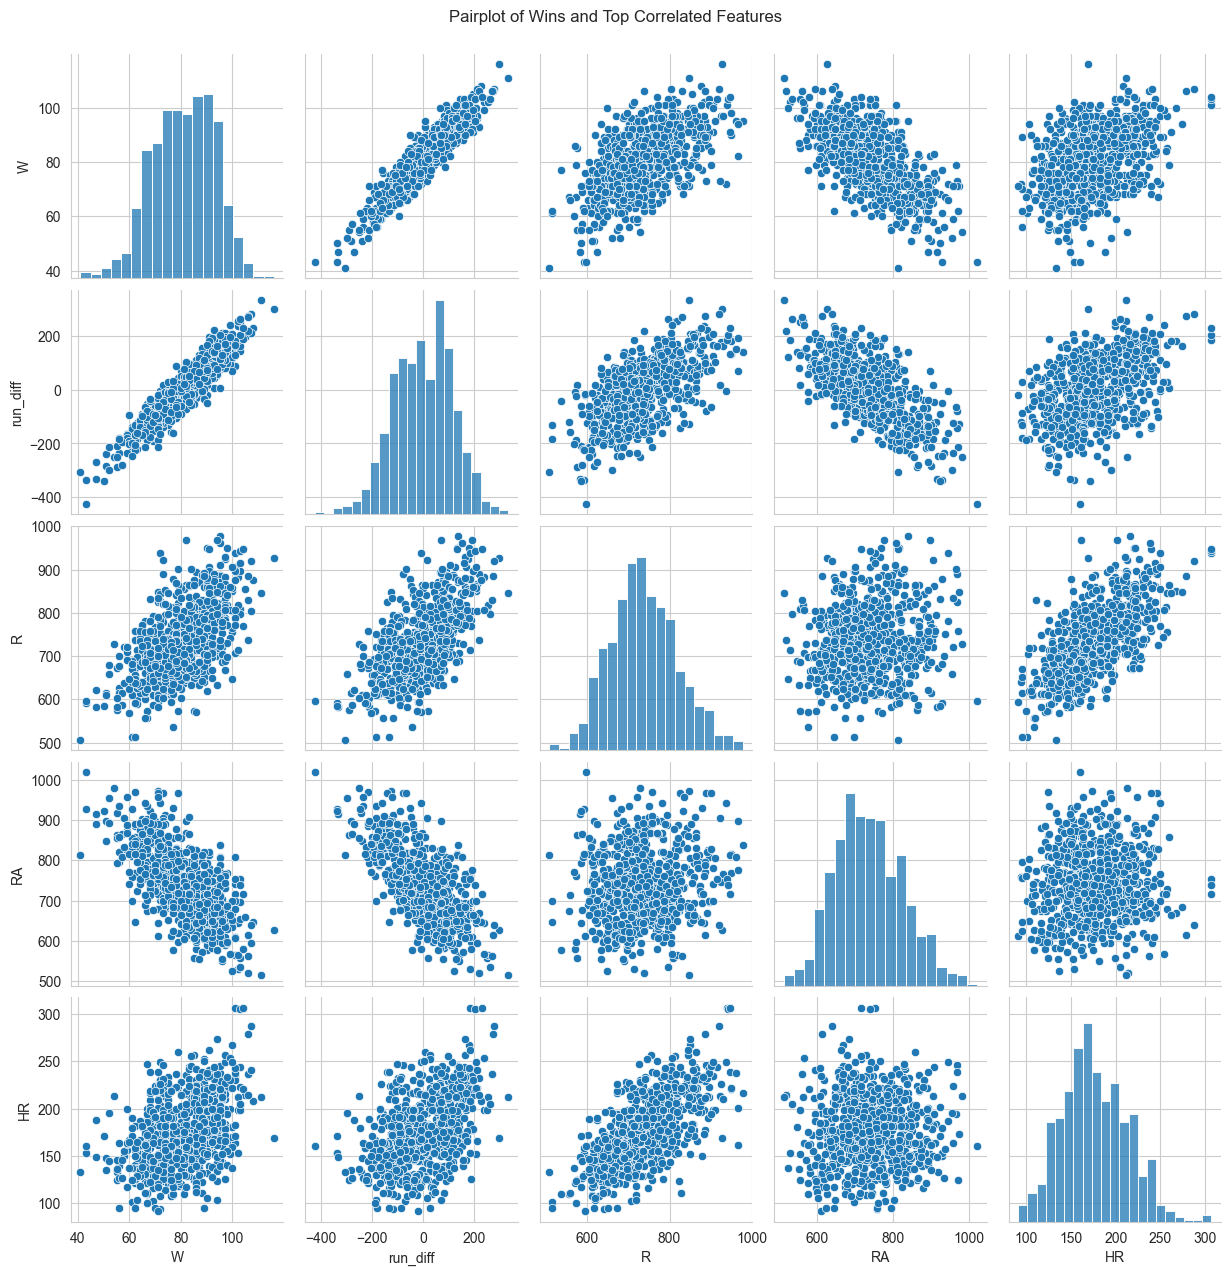

In [28]:
# Pairplot to look over the strongest correlations
sns.pairplot(df, vars=['W', 'run_diff', 'R', 'RA', 'HR'])
plt.suptitle("Pairplot of Wins and Top Correlated Features", y=1.02)
plt.show()


### Key Insights from Correlation Analysis

- Run differential is the strongest predictor of wins, emphasizing the importance of overall team performance.
- Both offensive (runs scored) and defensive (runs allowed, ERA) metrics significantly impact team success.
- Preventing runs is just as important as scoring runs when it comes to winning games.
- Home runs contribute to wins but are less predictive than total run production.
- Composite metrics like run differential provide stronger predictive power than individual statistics.